# MLS-SRTP Figures

This notebook generates figures from the Criterion benchmark results.

## Prerequisites: 

Run the benchmarks first:
```bash
cargo bench --package mls-srtp-core --bench srtp_throughput_criterion
```
Then copy results to the saved results directory:
```bash
cp -r target/criterion/srtp_throughput crates/mls-srtp-core/benches/results/criterion_srtp_throughput
```

In [15]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Global matplotlib style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

# Criterion writes per-benchmark results into subdirectories under protect/ and unprotect/
RESULTS_DIR = Path('crates/mls-srtp-core/benches/results/criterion_srtp_throughput/protect')
UNPROTECT_RESULTS_DIR = Path('crates/mls-srtp-core/benches/results/criterion_srtp_throughput/unprotect')
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

In [16]:
def load_criterion_results(results_dir: Path) -> dict:
    """Loads all Criterion benchmark results from the protect/ directory.
    
    Returns a dict mapping payload_size (int) -> {
        'label': str, 'payload_bytes': int, 'srtp_bytes': int,
        'mean_ns': float, 'std_ns': float, 'throughput_gbps': float
    }
    """
    results = {}
    
    for entry in sorted(results_dir.iterdir()):
        
        # skipping the top-level "report/" folder (Criterion's summary HTML)
        if not entry.is_dir() or entry.name == 'report':
            continue
        
        # each benchmark run has benchmark.json (metadata) and estimates.json (stats)
        bench_path = entry / 'new' / 'benchmark.json'
        est_path = entry / 'new' / 'estimates.json'
        
        if not bench_path.exists() or not est_path.exists():
            continue
        
        with open(bench_path) as f:
            bench = json.load(f)
        with open(est_path) as f:
            estimates = json.load(f)
        
        label = bench['value_str']
        
        # criterion's "Bytes" throughput field = full SRTP packet size
        # (12 B RTP header + payload + 16 B GCM tag)
        srtp_bytes = bench['throughput']['Bytes']
        
        mean_ns = estimates['mean']['point_estimate']
        std_ns = estimates['std_dev']['point_estimate']
        
        # extracting the numeric payload size from the label 
        # (e.g. "1424B_standard" -> 1424)
        match = re.match(r'(\d+)B', label)
        if match:
            payload_size = int(match.group(1))
        else:
            continue
        
        # bits/ns = Gbps (since 1 bit/ns = 1 Gbps)
        throughput_gbps = (srtp_bytes * 8) / mean_ns
        
        results[payload_size] = {
            'label': label,
            'payload_bytes': payload_size,
            'srtp_bytes': srtp_bytes,
            'mean_ns': mean_ns,
            'std_ns': std_ns,
            'throughput_gbps': throughput_gbps,
        }
    
    # sorting by payload size
    return dict(sorted(results.items()))


results = load_criterion_results(RESULTS_DIR)

print(f'Loaded {len(results)} benchmark results:')
print(f'{"Payload":>8s}  {"Mean (ns)":>10s}  {"Throughput":>12s}')
print('-' * 34)
for sz, r in results.items():
    print(f'{sz:>7d}B  {r["mean_ns"]:>10.1f}  {r["throughput_gbps"]:>10.2f} Gbps')

Loaded 15 benchmark results:
 Payload   Mean (ns)    Throughput
----------------------------------
     16B       103.6        3.40 Gbps
     32B       106.7        4.50 Gbps
     40B       108.9        4.99 Gbps
     64B       110.6        6.66 Gbps
    128B       118.9       10.50 Gbps
    160B       127.8       11.76 Gbps
    256B       141.7       16.03 Gbps
    512B       159.2       27.13 Gbps
    800B       186.4       35.54 Gbps
   1024B       213.8       39.36 Gbps
   1200B       228.5       42.99 Gbps
   1424B       259.3       44.79 Gbps
   2048B       319.1       52.05 Gbps
   4096B       533.5       61.84 Gbps
   8924B      1037.7       69.01 Gbps


In [17]:
# Loading decryption (unprotect) results using the same loader function
unprotect_results = load_criterion_results(UNPROTECT_RESULTS_DIR)

print(f'Loaded {len(unprotect_results)} unprotect benchmark results:')
print(f'{"Payload":>8s}  {"Mean (ns)":>10s}  {"Throughput":>12s}')
print('-' * 34)
for sz, r in unprotect_results.items():
    print(f'{sz:>7d}B  {r["mean_ns"]:>10.1f}  {r["throughput_gbps"]:>10.2f} Gbps')

Loaded 15 unprotect benchmark results:
 Payload   Mean (ns)    Throughput
----------------------------------
     16B       128.8        2.73 Gbps
     32B       126.4        3.80 Gbps
     40B       129.9        4.19 Gbps
     64B       127.0        5.80 Gbps
    128B       139.0        8.98 Gbps
    160B       145.0       10.38 Gbps
    256B       161.6       14.06 Gbps
    512B       195.4       22.11 Gbps
    800B       235.0       28.19 Gbps
   1024B       242.9       34.64 Gbps
   1200B       266.7       36.84 Gbps
   1424B       290.2       40.03 Gbps
   2048B       365.2       45.47 Gbps
   4096B       574.2       57.46 Gbps
   8924B      1173.4       61.03 Gbps


## Figure 1: SRTP Encryption Throughput vs. Uncompressed Video Bitrates

In [18]:
# --- Uncompressed video bitrates (ST 2110, 4:2:2, 10-bit) ---
# These are reference bitrates from the table provided by the EBU. 
# They are used as horizontal reference lines in the throughput plot 
# to show how SRTP compares to real workloads.

video_formats = [
    # (label,       bitrate_gbps, resolution_group)
    ('720p50',       0.96,  '720p'),
    ('720p60',       1.15,  '720p'),
    ('1080p50',      2.15,  '1080p'),
    ('1080p60',      2.58,  '1080p'),
    ('2160p50',      8.60,  '2160p'),
    ('2160p60',     10.32,  '2160p'),
    ('2160p120',    20.65,  '2160p'),
    ('2160p300',    51.62,  '2160p'),
    ('4320p50',     34.41,  '4320p'),
    ('4320p60',     41.29,  '4320p'),
]

# Color scheme by resolution family
resolution_colors = {
    '720p':  '#27ae60',
    '1080p': '#2980b9',
    '2160p': '#e67e22',
    '4320p': '#8e44ad',
}

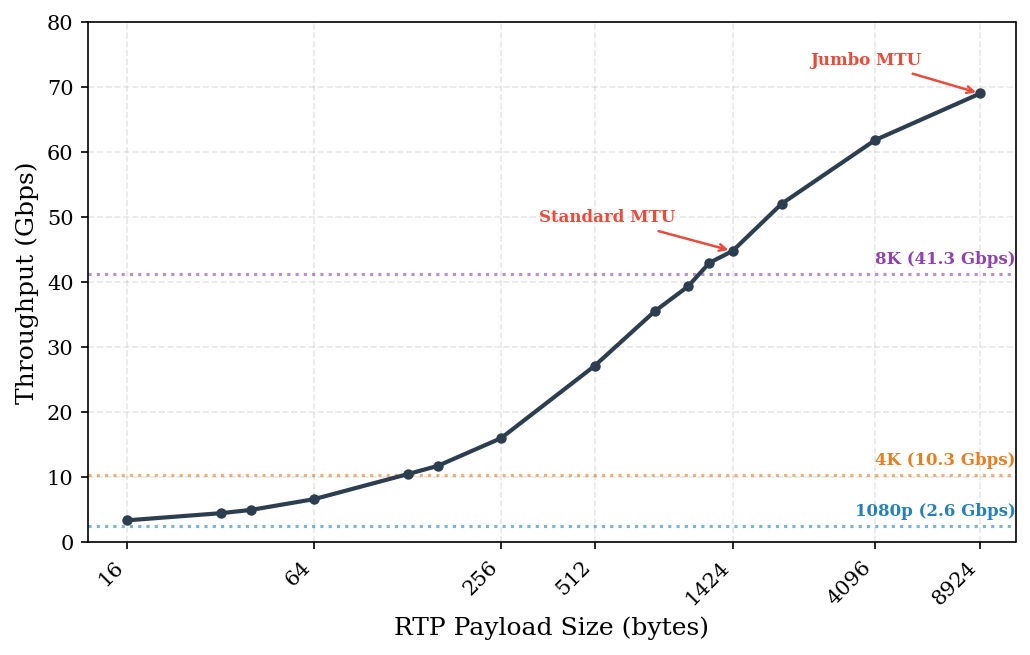

In [19]:
# Extracting sorted payload sizes and corresponding throughputs 
# from benchmark results
payload_sizes = np.array(list(results.keys()))
throughput_gbps = np.array([r['throughput_gbps'] for r in results.values()])

fig, ax = plt.subplots(figsize=(7, 4.5))

# --- SRTP throughput curve (measured data points connected by lines) ---
ax.plot(payload_sizes, throughput_gbps, 'o-', color='#2c3e50', linewidth=2,
        markersize=4, zorder=5)

# --- Annotating the two MTU-relevant payload sizes ---
highlights = {
    1424: ('Standard MTU', (-60, 14)),   # offset positions the label arrow
    8924: ('Jumbo MTU', (-55, 14)),
}
for sz, (lbl, offset) in highlights.items():
    if sz not in results:
        continue
    tp = results[sz]['throughput_gbps']
    ax.annotate(lbl, (sz, tp),
                textcoords='offset points', xytext=offset,
                fontsize=8, ha='center',
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2),
                color='#e74c3c', fontweight='bold')

# --- Video bitrate reference lines ---
# Showing 60fps entries as horizontal dashed lines so readers can compare
# SRTP throughput against real uncompressed video workloads.

# Upper limit of the y-axis 
y_max = 80

# Picking one representative frame rate per resolution for a clean plot
display_formats = {
    '1080p60': '1080p',
    '2160p60': '4K',
    '4320p60': '8K',
}

# Placing the format labels at the right edge of the plot, just above the line
for label, bitrate, res_group in video_formats:
    if label not in display_formats:
        continue
    display_label = display_formats[label]
    color = resolution_colors[res_group]
    ax.axhline(y=bitrate, color=color, linestyle=':', linewidth=1.5, alpha=0.6)
    ax.text(1.0, bitrate + 1.0, f'{display_label} ({bitrate:.1f} Gbps)',
            va='bottom', ha='right', fontsize=8, color=color, fontweight='bold',
            transform=ax.get_yaxis_transform())

# --- Axis formatting ---
ax.set_xscale('log', base=2)  # log2 scale suits the roughly-doubling payload sizes
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Throughput (Gbps)')

# Using payload sizes as labels
xtick_sizes = [16, 64, 256, 512, 1424, 4096, 8924]
ax.set_xticks(xtick_sizes)
ax.set_xticklabels([str(s) for s in xtick_sizes], rotation=45, ha='right')
ax.xaxis.set_minor_formatter(ticker.NullFormatter())  # hide minor tick labels

ax.set_ylim(0, y_max)
ax.set_xlim(12, payload_sizes[-1] * 1.3)

## Saving as PDF and PNG, and also showing the plot
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_srtp_throughput.pdf')
plt.savefig(FIGURES_DIR / 'fig1_srtp_throughput.png')
plt.show()

## Figure 2: SRTP Decryption Throughput vs. Uncompressed Video Bitrates

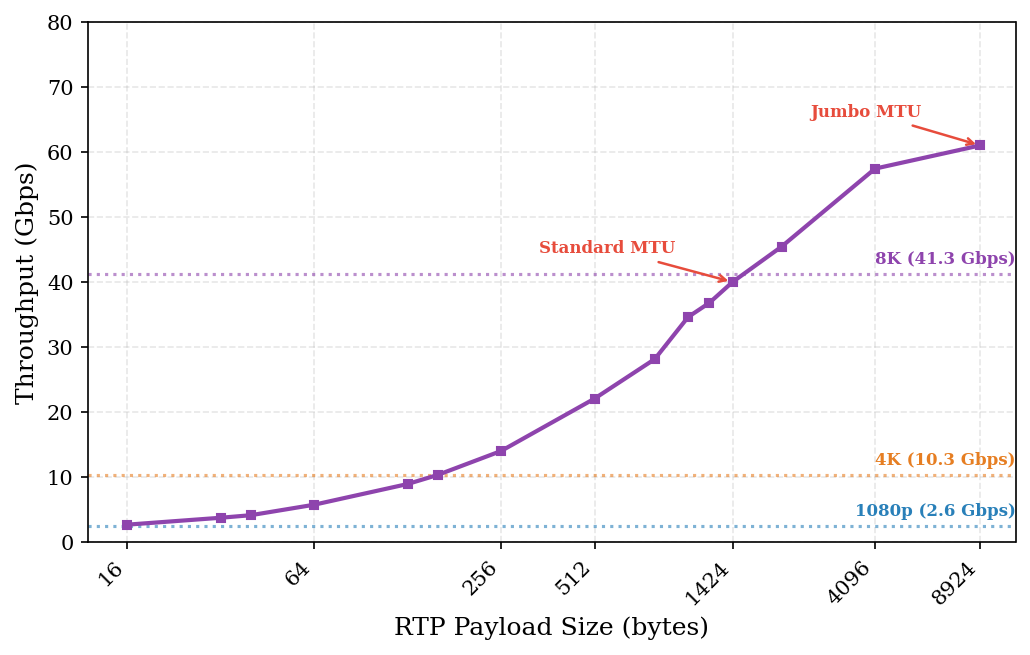

In [20]:
# Extracting sorted payload sizes and corresponding throughputs
# from unprotect (decryption) benchmark results
unprotect_payload_sizes = np.array(list(unprotect_results.keys()))
unprotect_throughput_gbps = np.array([r['throughput_gbps'] for r in unprotect_results.values()])

fig, ax = plt.subplots(figsize=(7, 4.5))

# --- SRTP decryption throughput curve ---
ax.plot(unprotect_payload_sizes, unprotect_throughput_gbps, 's-', color='#8e44ad',
        linewidth=2, markersize=4, zorder=5, label='unprotect (decrypt)')

# --- Annotating the two MTU-relevant payload sizes ---
highlights = {
    1424: ('Standard MTU', (-60, 14)),
    8924: ('Jumbo MTU', (-55, 14)),
}
for sz, (lbl, offset) in highlights.items():
    if sz not in unprotect_results:
        continue
    tp = unprotect_results[sz]['throughput_gbps']
    ax.annotate(lbl, (sz, tp),
                textcoords='offset points', xytext=offset,
                fontsize=8, ha='center',
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2),
                color='#e74c3c', fontweight='bold')

# --- Video bitrate reference lines (same as Figure 1) ---
y_max = 80

display_formats = {
    '1080p60': '1080p',
    '2160p60': '4K',
    '4320p60': '8K',
}

for label, bitrate, res_group in video_formats:
    if label not in display_formats:
        continue
    display_label = display_formats[label]
    color = resolution_colors[res_group]
    ax.axhline(y=bitrate, color=color, linestyle=':', linewidth=1.5, alpha=0.6)
    ax.text(1.0, bitrate + 1.0, f'{display_label} ({bitrate:.1f} Gbps)',
            va='bottom', ha='right', fontsize=8, color=color, fontweight='bold',
            transform=ax.get_yaxis_transform())

# --- Axis formatting ---
ax.set_xscale('log', base=2)
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Throughput (Gbps)')

xtick_sizes = [16, 64, 256, 512, 1424, 4096, 8924]
ax.set_xticks(xtick_sizes)
ax.set_xticklabels([str(s) for s in xtick_sizes], rotation=45, ha='right')
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

ax.set_ylim(0, y_max)
ax.set_xlim(12, unprotect_payload_sizes[-1] * 1.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_srtp_decryption_throughput.pdf')
plt.savefig(FIGURES_DIR / 'fig2_srtp_decryption_throughput.png')
plt.show()